In [1]:
# Install required dependencies via uv
import subprocess, sys
subprocess.check_call(['uv', 'pip', 'install', '--quiet', '-r', 'requirements.txt'])

0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
import requests
import json
import geopandas as gpd
import glob
import os
from scipy import stats
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')

# ── QVRS Global Style 
def set_quant_style():
    sns.set_theme(style='whitegrid')
    plt.rcParams.update({
        'axes.grid': True,
        'grid.color': '#EBEBEB',
        'grid.linewidth': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titleweight': 'bold',
        'axes.titlesize': 14,
        'axes.labelweight': 'bold',
        'axes.labelsize': 10,
        'xtick.major.size': 0,
        'ytick.major.size': 0,
        'figure.dpi': 120,
        'legend.frameon': False,
    })

# ── Semantic palette (consistent across all plots) 
ARCHETYPE_COLORS = {0: '#E63946', 1: '#F4A261', 2: '#264653', 3: '#2A9D8F'}
ARCHETYPE_LABELS = {0: 'Survivalist', 1: 'Transition', 2: 'Oligopoly', 3: 'Middle'}
ARCHETYPE_PALETTE = {v: ARCHETYPE_COLORS[k] for k, v in ARCHETYPE_LABELS.items()}
ARCHETYPE_ORDER  = ['Survivalist', 'Transition', 'Middle', 'Oligopoly']
SOURCE_PSA = 'Source: PSA 2021 Business Establishments Census | Philippine Statistics Authority'

set_quant_style()
LATEX_DIR = 'An_Econometric_Taxonomy_for_Policy__Quantifying_Structural_Vulnerability_via_K_Means_Clustering_of_Philippine_Industries'
IMAGES_DIR = 'images'
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(LATEX_DIR, exist_ok=True)

def save_fig(filename):
    """Helper to save figures to both central image folder and LaTeX source directory."""
    plt.savefig(os.path.join(IMAGES_DIR, filename), bbox_inches='tight', dpi=150)
    plt.savefig(os.path.join(LATEX_DIR, filename), bbox_inches='tight', dpi=150)
    print(f'Saved {filename}')

print('QVRS style loaded. Archetype palette ready.')


QVRS style loaded. Archetype palette ready.


In [3]:
BASE_DIR = os.getcwd()
FILE_PATH = os.path.join(BASE_DIR, 'data', 'main data set.xlsx')
print(f"Project Root: {BASE_DIR}")
print(f"Looking for data at: {FILE_PATH}")
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"CRITICAL: Data file missing at {FILE_PATH}")

Project Root: /Users/hoshi/Local Code/Taxonomy
Looking for data at: /Users/hoshi/Local Code/Taxonomy/data/main data set.xlsx


In [4]:
#Data Cleaning

def load_and_clean_psa_data(path):
    print(f"Loading file from: {path}...")
    xls = pd.ExcelFile(path)
    print(f"Sheets found: {xls.sheet_names}")
    

    df3 = pd.read_excel(xls, sheet_name='Table 3', header=None)
    
    
    df3_clean = df3.dropna(subset=[0])
    df3_clean = df3_clean[df3_clean[0].astype(str).str.contains(r'[A-Z]\d{3}', regex=True)]
    
    df3_final = df3_clean.iloc[:, [0, 1, 2]].copy()
    df3_final.columns = ['industry_raw', 'total_est', 'total_emp']
    
    df3_final['psic_code'] = df3_final['industry_raw'].str.split(' -').str[0].str.strip()
    
    cols_to_clean = ['total_est', 'total_emp']
    for col in cols_to_clean:
        df3_final[col] = pd.to_numeric(df3_final[col].astype(str).str.replace(',', ''), errors='coerce')

    df5 = pd.read_excel(xls, sheet_name='Table 5', header=None)
    
    df5_clean = df5.dropna(subset=[0])
    df5_clean = df5_clean[df5_clean[0].astype(str).str.contains(r'[A-Z]\d{3}', regex=True)]
    
    df5_final = df5_clean.iloc[:, [0, 2, 3, 4, 5]].copy()
    df5_final.columns = ['industry_raw', 'micro', 'small', 'medium', 'large']
    
    df5_final['psic_code'] = df5_final['industry_raw'].str.split(' -').str[0].str.strip()
    
    cols_to_clean_5 = ['micro', 'small', 'medium', 'large']
    for col in cols_to_clean_5:
        df5_final[col] = pd.to_numeric(df5_final[col].astype(str).str.replace(',', '').str.replace('-', '0'), errors='coerce').fillna(0)

    master_df = pd.merge(df3_final[['psic_code', 'total_est', 'total_emp']], 
                         df5_final[['psic_code', 'micro', 'small', 'medium', 'large']], 
                         on='psic_code', 
                         how='inner')
    
    print(f"Successfully cleaned and merged. Total Industries: {len(master_df)}")
    return master_df

df = load_and_clean_psa_data(FILE_PATH)
df.head()

Loading file from: /Users/hoshi/Local Code/Taxonomy/data/main data set.xlsx...


Sheets found: ['List of Tables', 'Table 1', 'Table 2', 'Table 3', 'Table 4', 'Table 5', 'Table 6', 'Table 7', 'Table 8', 'Table 9']
Successfully cleaned and merged. Total Industries: 228


,psic_code,total_est,total_emp,micro,small,medium,large
0,A011,1141,25106,721,351,54,15
1,A012,619,65707,293,223,38,65
2,A013,101,589,85,16,0,0
3,A014,4780,51337,3510,1221,35,14
4,A015,911,20356,508,370,20,13


In [5]:
#Feature Enghineering

#Removes any industry with zero establishments.
df = df[df['total_est'] > 0].copy()

#Creates four new variables by normalizing the raw counts against the total population of the industry.
df['avg_firm_size'] = df['total_emp'] / df['total_est']
df['sme_density'] = (df['small'] + df['medium']) / df['total_est']
df['large_density'] = df['large'] / df['total_est']
df['micro_density'] = df['micro'] / df['total_est']

#Shannon Entropy Calculation
def calculate_entropy(row):
    counts = np.array([row['micro'], row['small'], row['medium'], row['large']])
    total = np.sum(counts)
    
    if total == 0:
        return 0
        
    probs = counts / total
    
    probs = probs[probs > 0]
    
    return -np.sum(probs * np.log(probs))

df['shannon_entropy'] = df.apply(calculate_entropy, axis=1)

print("Data Ready for Clustering.")
print(df[['psic_code', 'avg_firm_size', 'sme_density', 'shannon_entropy']].head())

Data Ready for Clustering.
  psic_code  avg_firm_size  sme_density  shannon_entropy
0      A011      22.003506     0.354952         0.854031
1      A012     106.150242     0.421648         1.129796
2      A013       5.831683     0.158416         0.437034
3      A014      10.739958     0.262762         0.628475
4      A015      22.344676     0.428101         0.836124


In [6]:
#Z Score Outlier Detection
print("\n--- Z-SCORE OUTLIER DETECTION ---")
# Calculate Z-scores for Avg Firm Size
z_scores = np.abs(stats.zscore(df['avg_firm_size']))
outliers = df[z_scores > 3] # Standard threshold is 3
print(f"Found {len(outliers)} structural outliers (Z > 3):")
print(outliers[['psic_code', 'avg_firm_size', 'micro_density']])


--- Z-SCORE OUTLIER DETECTION ---
Found 4 structural outliers (Z > 3):
    psic_code  avg_firm_size  micro_density
58       C261     918.993548       0.090323
59       C262     597.340000       0.280000
78       C303     604.285714       0.142857
188      N783    1172.545455       0.272727


--- CLUSTER VALIDATION METRICS ---
k=2 | Inertia: 405.39 | Silhouette: 0.5777
k=3 | Inertia: 245.00 | Silhouette: 0.4721
k=4 | Inertia: 146.13 | Silhouette: 0.4946
k=5 | Inertia: 114.72 | Silhouette: 0.4431
k=6 | Inertia: 92.72 | Silhouette: 0.4497
k=7 | Inertia: 76.83 | Silhouette: 0.4513


Saved fig_elbow_silhouette.png


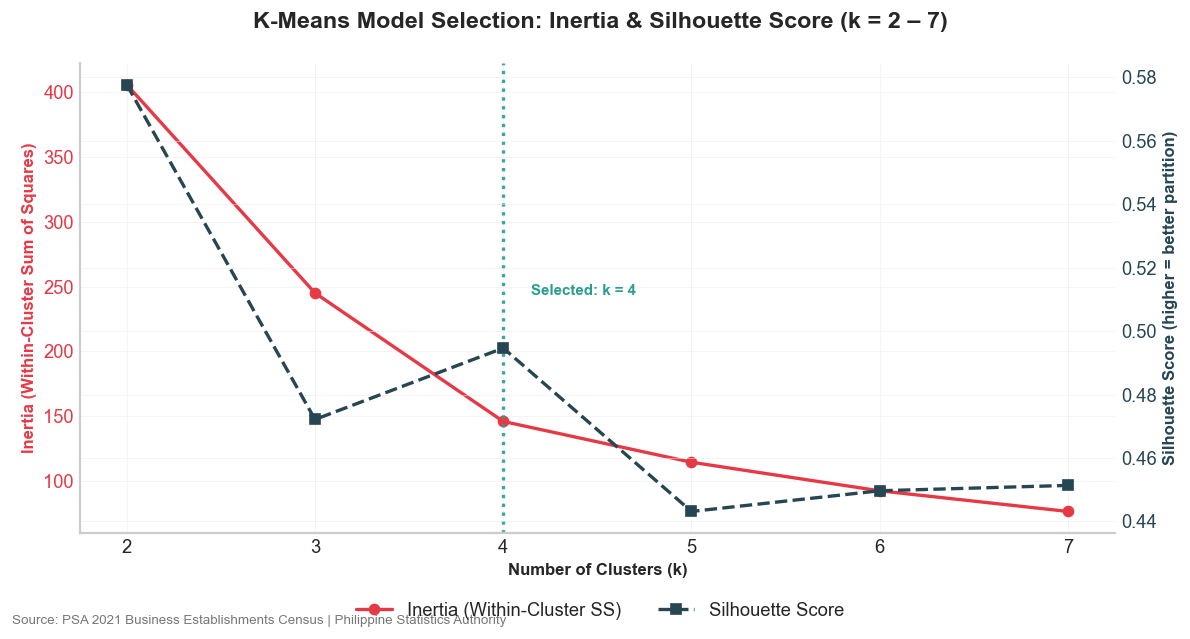


--- EXECUTING FINAL MODEL (k=4) ---
Saved fig_heatmap_centroids.png


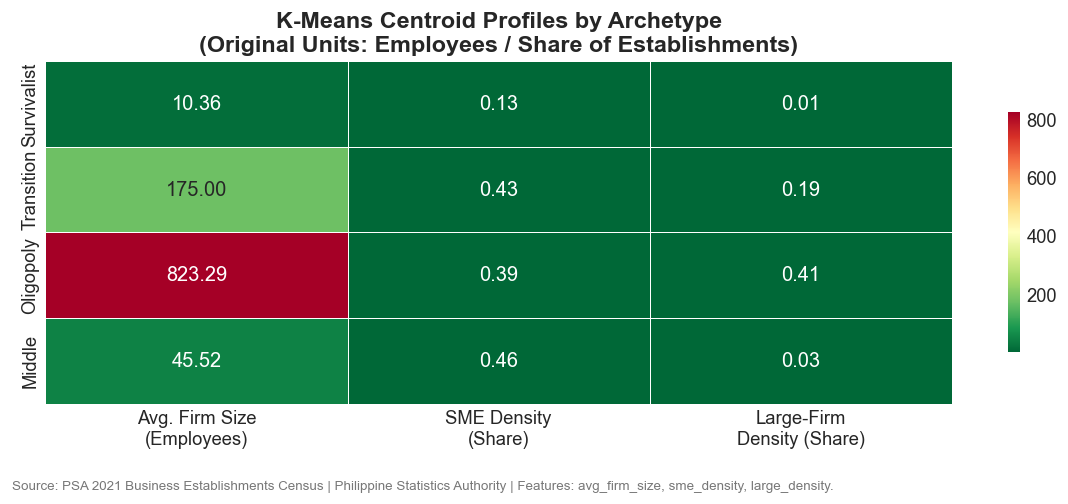

Saved fig_cluster_dualism_map.png


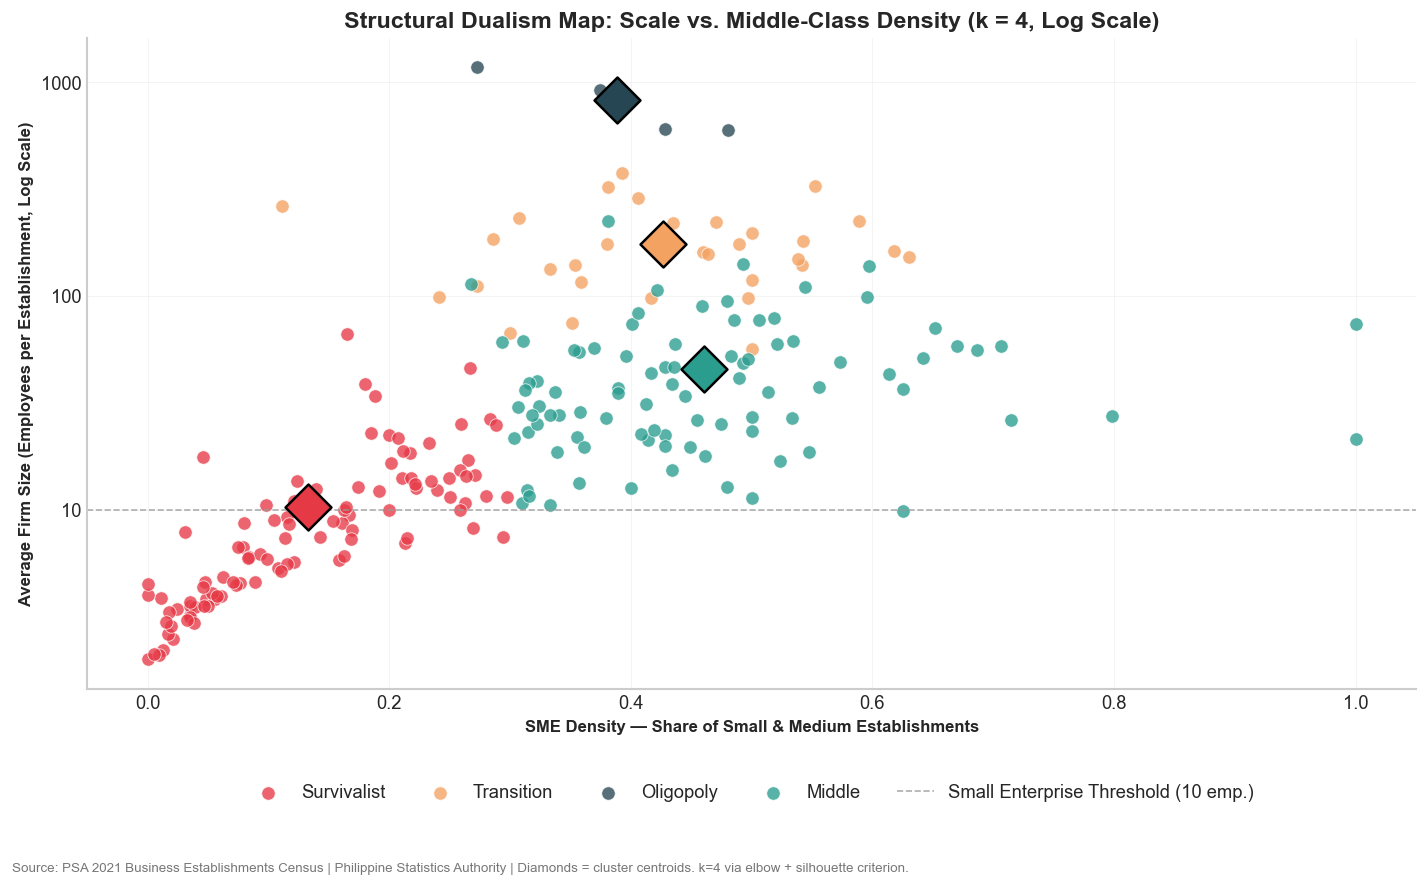

In [7]:
#Setup Features & Scaling
features = ['avg_firm_size', 'sme_density', 'large_density']
df_model = df.dropna(subset=features).copy()
X = df_model[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Dual Validation Loop (Elbow & Silhouette)
inertia = []
silhouette_scores = []
k_range = range(2, 8)

print('--- CLUSTER VALIDATION METRICS ---')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k} | Inertia: {km.inertia_:.2f} | Silhouette: {score:.4f}')

# ── PLOT 1: Dual Validation (Elbow + Silhouette) 
set_quant_style()
k_list = list(k_range)
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_list, inertia, marker='o', color='#E63946', linewidth=2,
         label='Inertia (Within-Cluster SS)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color='#E63946', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#E63946')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axvline(x=4, color='#2A9D8F', linestyle=':', linewidth=2, alpha=0.9)
ax1.annotate('Selected: k = 4', xy=(4, max(inertia)*0.55),
             xytext=(4.15, max(inertia)*0.60),
             fontsize=9, color='#2A9D8F', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(k_list, silhouette_scores, marker='s', color='#264653', linewidth=2,
         linestyle='--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score (higher = better partition)', color='#264653', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#264653')
ax2.spines['top'].set_visible(False)

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labs1 + labs2, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.06), frameon=False)
fig.suptitle('K-Means Model Selection: Inertia & Silhouette Score (k = 2 – 7)',
             fontweight='bold', fontsize=14)
fig.text(0.01, -0.04, SOURCE_PSA, fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_elbow_silhouette.png')
plt.show()

#Final Model Execution (k=4)
optimal_k = 4
print(f'\n--- EXECUTING FINAL MODEL (k={optimal_k}) ---')
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_mapping = {0: 'Survivalist', 1: 'Transition', 2: 'Oligopoly', 3: 'Middle'}
df['Archetype'] = df['cluster'].map(cluster_mapping)

centroids_scaled   = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# ── PLOT 2: Centroid Heatmap 
set_quant_style()
feat_labels = ['Avg. Firm Size\n(Employees)', 'SME Density\n(Share)', 'Large-Firm\nDensity (Share)']
row_labels  = [ARCHETYPE_LABELS[i] for i in range(optimal_k)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(centroids_original, annot=True, fmt='.2f', cmap='RdYlGn_r',
            xticklabels=feat_labels, yticklabels=row_labels,
            ax=ax, linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.7})
ax.set_title('K-Means Centroid Profiles by Archetype\n(Original Units: Employees / Share of Establishments)',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
fig.text(0.01, -0.04, SOURCE_PSA + ' | Features: avg_firm_size, sme_density, large_density.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_heatmap_centroids.png')
plt.show()

# ── PLOT 3: Structural Dualism Scatter (SME density vs avg_firm_size) 
set_quant_style()
fig, ax = plt.subplots(figsize=(12, 7))

for cid, label in ARCHETYPE_LABELS.items():
    mask = df['cluster'] == cid
    ax.scatter(df.loc[mask, 'sme_density'], df.loc[mask, 'avg_firm_size'],
               color=ARCHETYPE_COLORS[cid], label=label,
               s=65, alpha=0.78, edgecolor='white', linewidth=0.5)

for i in range(optimal_k):
    ax.scatter(centroids_original[i, 1], centroids_original[i, 0],
               color=ARCHETYPE_COLORS[i], s=380, marker='D',
               edgecolor='black', linewidth=1.5, zorder=10)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.axhline(y=10, color='#999999', linestyle='--', linewidth=1,
           alpha=0.8, label='Small Enterprise Threshold (10 emp.)')
ax.set_title('Structural Dualism Map: Scale vs. Middle-Class Density (k = 4, Log Scale)',
             fontweight='bold')
ax.set_xlabel('SME Density — Share of Small & Medium Establishments')
ax.set_ylabel('Average Firm Size (Employees per Establishment, Log Scale)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
fig.text(0.01, -0.05,
         SOURCE_PSA + ' | Diamonds = cluster centroids. k=4 via elbow + silhouette criterion.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_cluster_dualism_map.png')
plt.show()


Saved fig_entropy_boxplot.png


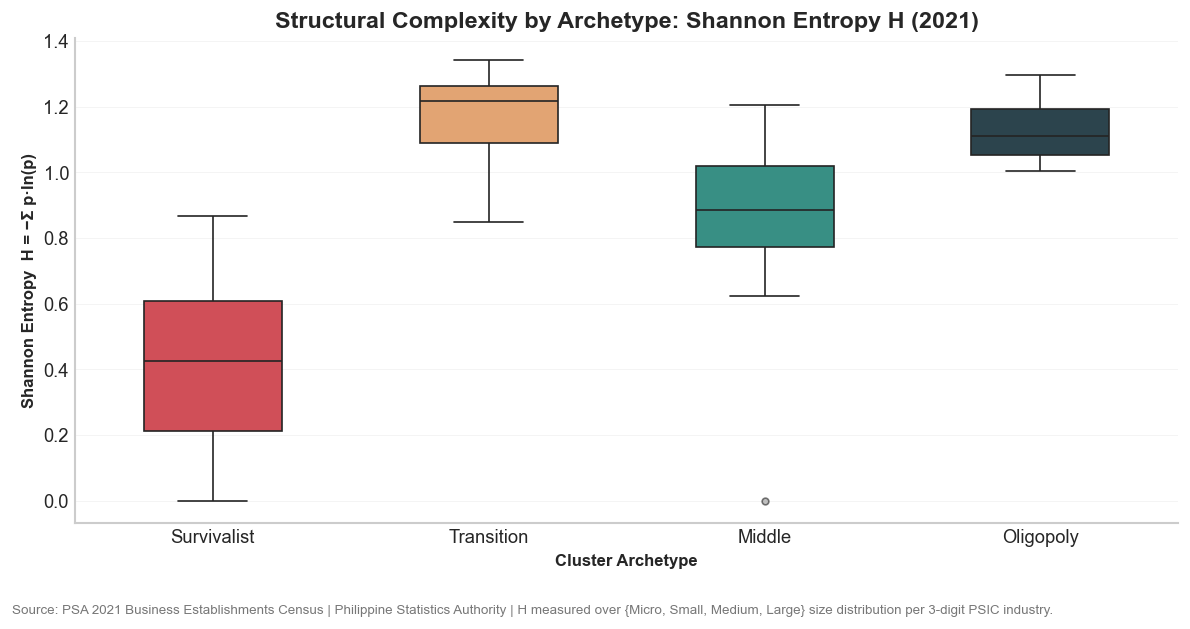


--- VULNERABILITY STRESS TEST ---
Pearson r (pct_survivalist vs total_closures): 0.4397

Top 5 Sections by Total Closures:
   section  pct_survivalist  total_closures
6        G         0.894737          222881
8        I         1.000000           96049
2        C         0.352113           54044
17       S         1.000000           43666
9        J         0.153846           29977
Saved fig_regression_stress_test.png


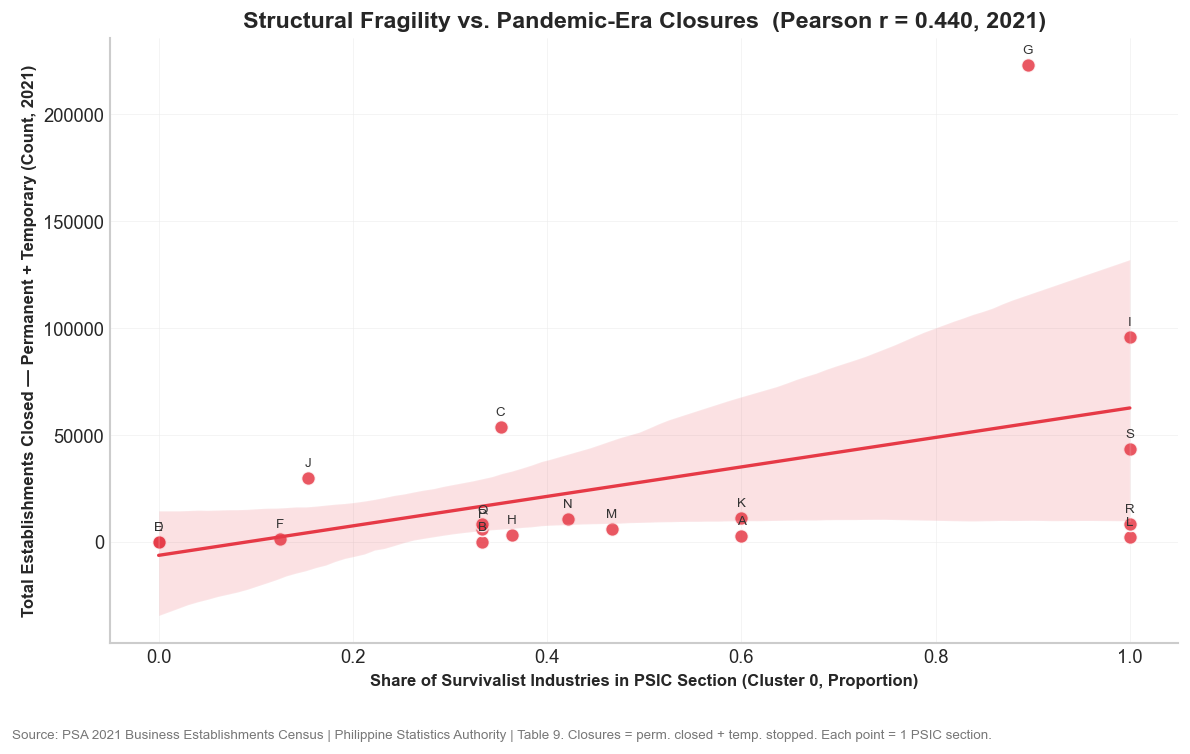

In [8]:
#ENTROPY VALIDATION

# ── PLOT 4: Shannon Entropy Boxplot by Archetype 
set_quant_style()
df['Archetype'] = df['cluster'].map(ARCHETYPE_LABELS)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x='Archetype', y='shannon_entropy', data=df,
            order=ARCHETYPE_ORDER, palette=ARCHETYPE_PALETTE,
            width=0.5, ax=ax,
            flierprops=dict(marker='o', markerfacecolor='#999999',
                            markersize=4, linestyle='none', alpha=0.6))
ax.set_title('Structural Complexity by Archetype: Shannon Entropy H (2021)',
             fontweight='bold')
ax.set_xlabel('Cluster Archetype')
ax.set_ylabel('Shannon Entropy  H = −Σ p·ln(p)')
fig.text(0.01, -0.04,
         SOURCE_PSA + ' | H measured over {Micro, Small, Medium, Large} size distribution per 3-digit PSIC industry.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_entropy_boxplot.png')
plt.show()

df['section'] = df['psic_code'].astype(str).str[0]

xls = pd.ExcelFile(FILE_PATH)
df9 = pd.read_excel(xls, sheet_name='Table 9', header=None)
df9_clean = df9[df9[0].astype(str).str.contains(r'^[A-S] -', regex=True, na=False)].copy()
df9_final = df9_clean.iloc[:, [0, 2, 3]].copy()
df9_final.columns = ['section_raw', 'perm_closed', 'temp_stopped']
df9_final['section'] = df9_final['section_raw'].str.split(' -').str[0].str.strip()
for col in ['perm_closed', 'temp_stopped']:
    df9_final[col] = pd.to_numeric(
        df9_final[col].astype(str).str.replace(',', ''), errors='coerce')
df9_final['total_closures'] = df9_final['perm_closed'] + df9_final['temp_stopped']

section_profile = df.groupby('section')['cluster'].apply(
    lambda x: (x == 0).mean()).reset_index()
section_profile.columns = ['section', 'pct_survivalist']
vulnerability_df = pd.merge(
    section_profile, df9_final[['section', 'total_closures']], on='section', how='inner')

corr = vulnerability_df['pct_survivalist'].corr(vulnerability_df['total_closures'])
print(f'\n--- VULNERABILITY STRESS TEST ---')
print(f'Pearson r (pct_survivalist vs total_closures): {corr:.4f}')
print('\nTop 5 Sections by Total Closures:')
print(vulnerability_df.sort_values('total_closures', ascending=False).head().to_string())

# ── PLOT 5: Stress Test Regression 
set_quant_style()
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='pct_survivalist', y='total_closures', data=vulnerability_df,
            color='#E63946',
            scatter_kws=dict(s=70, alpha=0.85, edgecolors='white'),
            line_kws=dict(linewidth=2), ax=ax)
for _, row in vulnerability_df.iterrows():
    ax.annotate(row['section'],
                (row['pct_survivalist'], row['total_closures']),
                fontsize=8, color='#333333', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')
ax.set_title(
    f'Structural Fragility vs. Pandemic-Era Closures  (Pearson r = {corr:.3f}, 2021)',
    fontweight='bold')
ax.set_xlabel('Share of Survivalist Industries in PSIC Section (Cluster 0, Proportion)')
ax.set_ylabel('Total Establishments Closed — Permanent + Temporary (Count, 2021)')
fig.text(0.01, -0.04,
         SOURCE_PSA + ' | Table 9. Closures = perm. closed + temp. stopped. Each point = 1 PSIC section.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_regression_stress_test.png')
plt.show()



=== CELL 11: CLUSTER STABILITY ANALYSIS ===
Fitting K-Means k=4 for 50 seeds...


Computing pairwise ARI across all 50 fits...



--- Stability Results ---
Pairwise comparisons : 1,225
Mean ARI             : 0.970678
Std Dev              : 0.037304
Min / Max ARI        : 0.908867 / 1.000000
Verdict: HIGHLY STABLE (ARI > 0.90)
Saved fig_cluster_stability_ari.png


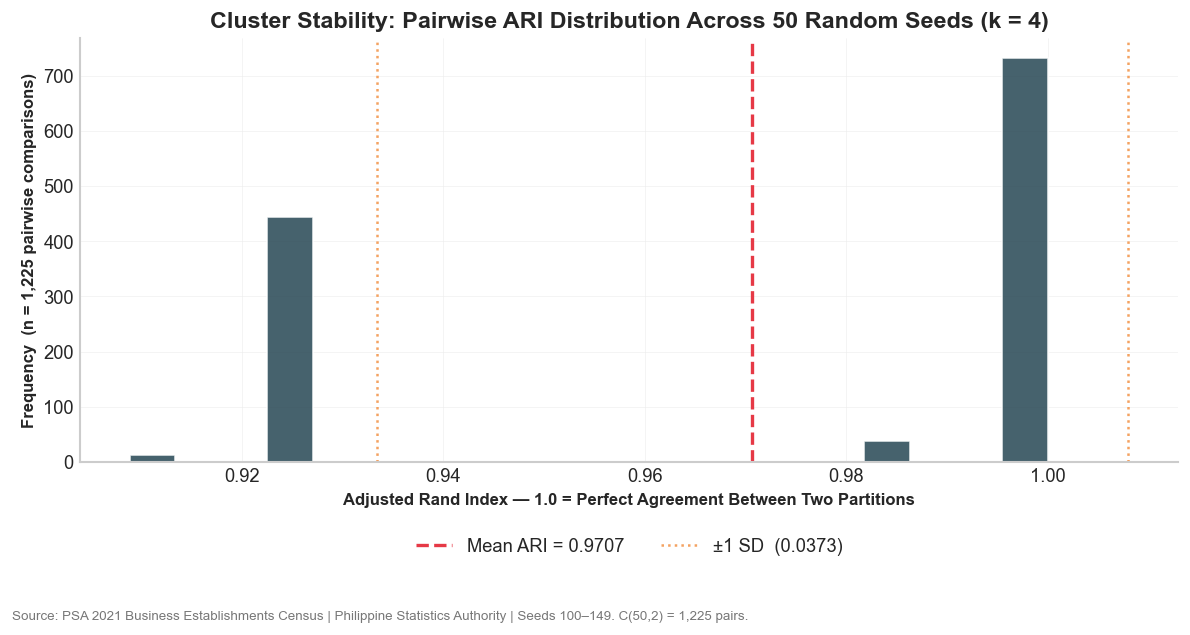


Conclusion: Mean ARI = 0.9707 → HIGHLY STABLE (ARI > 0.90)


In [9]:
## CELL 11: CLUSTER STABILITY ANALYSIS
print('\n=== CELL 11: CLUSTER STABILITY ANALYSIS ===')

from sklearn.metrics import adjusted_rand_score
import itertools

n_seeds = 50
random_seeds = list(range(100, 100 + n_seeds))
cluster_assignments = []

print(f'Fitting K-Means k=4 for {n_seeds} seeds...')
for seed in random_seeds:
    km_temp = KMeans(n_clusters=4, random_state=seed, n_init=10)
    cluster_assignments.append(km_temp.fit_predict(X_scaled))

print(f'Computing pairwise ARI across all {n_seeds} fits...')
ari_values = [adjusted_rand_score(cluster_assignments[i], cluster_assignments[j])
              for i, j in itertools.combinations(range(n_seeds), 2)]

mean_ari = np.mean(ari_values)
std_ari  = np.std(ari_values)
min_ari  = np.min(ari_values)
max_ari  = np.max(ari_values)

print(f'\n--- Stability Results ---')
print(f'Pairwise comparisons : {len(ari_values):,}')
print(f'Mean ARI             : {mean_ari:.6f}')
print(f'Std Dev              : {std_ari:.6f}')
print(f'Min / Max ARI        : {min_ari:.6f} / {max_ari:.6f}')

verdict = 'HIGHLY STABLE (ARI > 0.90)' if mean_ari > 0.9 else (
          'GOOD STABILITY (ARI > 0.70)' if mean_ari > 0.7 else 'UNSTABLE')
print(f'Verdict: {verdict}')

#  PLOT 6: ARI Distribution Histogram 
set_quant_style()
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(ari_values, bins=20, color='#264653', edgecolor='white', alpha=0.85)
ax.axvline(mean_ari, color='#E63946', linestyle='--', linewidth=2,
           label=f'Mean ARI = {mean_ari:.4f}')
ax.axvline(mean_ari - std_ari, color='#F4A261', linestyle=':', linewidth=1.5,
           label=f'±1 SD  ({std_ari:.4f})')
ax.axvline(mean_ari + std_ari, color='#F4A261', linestyle=':', linewidth=1.5)

ax.set_title(
    'Cluster Stability: Pairwise ARI Distribution Across 50 Random Seeds (k = 4)',
    fontweight='bold')
ax.set_xlabel('Adjusted Rand Index — 1.0 = Perfect Agreement Between Two Partitions')
ax.set_ylabel(f'Frequency  (n = {len(ari_values):,} pairwise comparisons)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)
fig.text(0.01, -0.05,
         SOURCE_PSA + f' | Seeds 100–149. C(50,2) = {len(ari_values):,} pairs.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_cluster_stability_ari.png')
plt.show()

print(f'\nConclusion: Mean ARI = {mean_ari:.4f} → {verdict}')


In [10]:
## CELL 12: FULL REGRESSION OUTPUT
print("\n=== CELL 12: FULL REGRESSION OUTPUT (OLS) ===")

import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

print("Running OLS regression: total_closures ~ pct_survivalist")
print(f"Sample size: {len(vulnerability_df)} sections")

# Prepare regression data
X_reg = vulnerability_df[['pct_survivalist']].values
y_reg = vulnerability_df['total_closures'].values

# Add constant for intercept
X_reg_with_const = add_constant(X_reg)

# Fit OLS model
model = sm.OLS(y_reg, X_reg_with_const)
results = model.fit()

# Print full regression summary
print("\n" + "="*80)
print("OLS REGRESSION SUMMARY")
print("="*80)
print(results.summary())

# Extract key statistics
r_squared = results.rsquared
adj_r_squared = results.rsquared_adj
f_statistic = results.fvalue
f_pvalue = results.f_pvalue
n_obs = results.nobs

# Extract coefficient details
coef_values = results.params
std_errors = results.bse
t_stats = results.tvalues
p_values = results.pvalues
conf_int = results.conf_int()

print("\n" + "="*80)
print("COEFFICIENT TABLE")
print("="*80)
coef_table = pd.DataFrame({
    'Coefficient': coef_values,
    'Std Error': std_errors,
    't-statistic': t_stats,
    'p-value': p_values,
    'CI Lower (95%)': conf_int[0],
    'CI Upper (95%)': conf_int[1]
})
print(coef_table.to_string())

print("\n" + "="*80)
print("MODEL FIT STATISTICS")
print("="*80)
print(f"R-squared: {r_squared:.6f}")
print(f"Adjusted R-squared: {adj_r_squared:.6f}")
print(f"F-statistic: {f_statistic:.4f}")
print(f"Prob (F-statistic): {f_pvalue:.6f}")
print(f"Number of observations: {n_obs}")

# Interpretation
print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
intercept = coef_values[0]
slope = coef_values[1]
slope_pval = p_values[1]

print(f"Intercept: {intercept:.4f}")
print(f"Slope (pct_survivalist coefficient): {slope:.4f}")
print(f"  p-value: {slope_pval:.6f}")

if slope_pval < 0.05:
    direction = "positive" if slope > 0 else "negative"
    print(f"  Interpretation: There is a statistically significant {direction} relationship.")
else:
    print(f"  Interpretation: Coefficient is NOT statistically significant at 5% level.")

print(f"\nModel explains {r_squared*100:.2f}% of the variance in closures.")


=== CELL 12: FULL REGRESSION OUTPUT (OLS) ===


Running OLS regression: total_closures ~ pct_survivalist
Sample size: 18 sections

OLS REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     3.834
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0679
Time:                        01:37:07   Log-Likelihood:                -219.45
No. Observations:                  18   AIC:                             442.9
Df Residuals:                      16   BIC:                             444.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------


=== CELL 13: K-MEDOIDS ROBUSTNESS CHECK ===
ARI: 0.8615
Saved fig_kmedoids_robustness.png


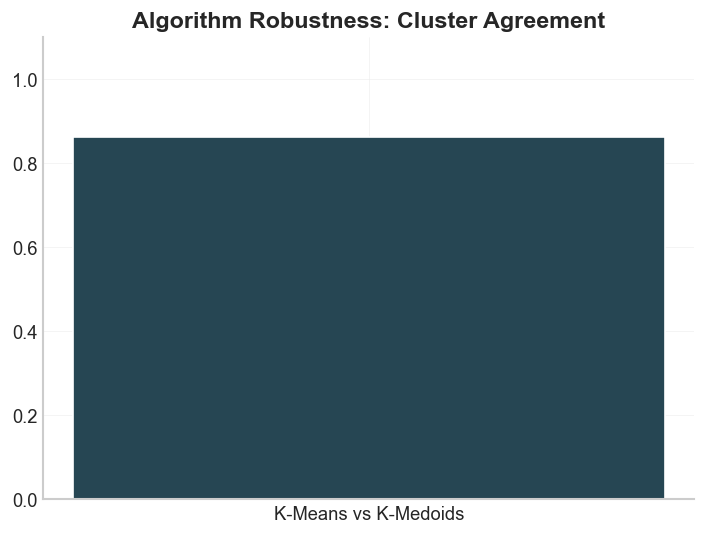

In [11]:
## CELL 13: K-MEDOIDS ROBUSTNESS CHECK
print('\n=== CELL 13: K-MEDOIDS ROBUSTNESS CHECK ===')

from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment

def kmedoids_fit(X, k, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(X)
    medoid_idx = rng.choice(n, size=k, replace=False)
    for _ in range(max_iter):
        dists = np.array([[np.sum((X[i] - X[m])**2) for m in medoid_idx] for i in range(n)])
        labels = np.argmin(dists, axis=1)
        new_medoids = medoid_idx.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members) == 0: continue
            intra = np.sum(np.array([[np.sum((X[i]-X[j])**2) for j in members] for i in members]), axis=1)
            new_medoids[c] = members[np.argmin(intra)]
        if np.array_equal(np.sort(new_medoids), np.sort(medoid_idx)): break
        medoid_idx = new_medoids
    dists = np.array([[np.sum((X[i]-X[m])**2) for i in range(n) for m in medoid_idx]]).reshape(n, k)
    return np.argmin(dists, axis=1)

kmedoids_labels_raw = kmedoids_fit(X_scaled, k=4, random_state=42)
kmeans_labels = df['cluster'].values

overlap_matrix = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        overlap_matrix[i, j] = np.sum((kmeans_labels == i) & (kmedoids_labels_raw == j))

row_ind, col_ind = linear_sum_assignment(overlap_matrix, maximize=True)
label_map = {col_ind[i]: row_ind[i] for i in range(4)}
kmedoids_labels = np.array([label_map[l] for l in kmedoids_labels_raw])

ari_km_vs_kmedoids = adjusted_rand_score(kmeans_labels, kmedoids_labels)
print(f'ARI: {ari_km_vs_kmedoids:.4f}')

# PLOT 7: ARI Bar Chart (Robustness Check)
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['K-Means vs K-Medoids'], [ari_km_vs_kmedoids], color='#264653', width=0.35)
ax.set_ylim(0, 1.1)
ax.set_title('Algorithm Robustness: Cluster Agreement', fontweight='bold')
save_fig('fig_kmedoids_robustness.png')
plt.show()

In [12]:
## CELL 14: ENTROPY EDGE CASE DOCUMENTATION
print("\n=== CELL 14: ENTROPY EDGE CASE DOCUMENTATION ===")

print("\nAnalyzing entropy calculation for edge cases with zero counts in size buckets...")

# Count industries with at least one zero in size buckets
zero_count = 0
industries_with_zeros = []

for idx, row in df.iterrows():
    sizes = [row['micro'], row['small'], row['medium'], row['large']]
    if 0 in sizes:
        zero_count += 1
        industries_with_zeros.append({
            'psic_code': row['psic_code'],
            'micro': row['micro'],
            'small': row['small'],
            'medium': row['medium'],
            'large': row['large'],
            'total': sum(sizes),
            'shannon_entropy': row['shannon_entropy']
        })

print(f"\n--- Zero Count Analysis ---")
print(f"Total 3-digit industries analyzed: {len(df)}")
print(f"Industries with at least one size bucket = 0: {zero_count}")
print(f"Percentage: {(zero_count/len(df))*100:.2f}%")

print(f"\nSample of industries with zero-valued buckets (first 10):")
zero_df = pd.DataFrame(industries_with_zeros[:10])
print(zero_df[['psic_code', 'micro', 'small', 'medium', 'large', 'shannon_entropy']].to_string(index=False))

# Verify entropy calculation handles 0*ln(0)=0 correctly
print(f"\n--- Entropy Calculation Verification ---")
print("The entropy function filters out zero probabilities before computing log:")
print("""
    def calculate_entropy(row):
        counts = np.array([row['micro'], row['small'], row['medium'], row['large']])
        total = np.sum(counts)
        if total == 0:
            return 0
        probs = counts / total
        probs = probs[probs > 0]  # <-- FILTERS OUT ZEROS
        return -np.sum(probs * np.log(probs))
""")

print("This approach correctly avoids 0*ln(0) undefined behavior.")

# Demonstrate on a specific example
print(f"\nDemonstration with example industry (first zero-case):")
if len(industries_with_zeros) > 0:
    example = industries_with_zeros[0]
    psic = example['psic_code']
    micro = example['micro']
    small = example['small']
    medium = example['medium']
    large = example['large']
    total = example['total']
    
    print(f"PSIC Code: {psic}")
    print(f"Size Distribution: Micro={micro}, Small={small}, Medium={medium}, Large={large}")
    print(f"Total: {total}")
    
    # Manual calculation
    counts = np.array([micro, small, medium, large])
    probs = counts / total
    print(f"Probabilities: {probs}")
    
    probs_nonzero = probs[probs > 0]
    print(f"Non-zero probabilities: {probs_nonzero}")
    
    entropy_manual = -np.sum(probs_nonzero * np.log(probs_nonzero))
    entropy_from_df = example['shannon_entropy']
    
    print(f"Manually calculated entropy: {entropy_manual:.6f}")
    print(f"Entropy from dataframe: {entropy_from_df:.6f}")
    print(f"Match: {np.isclose(entropy_manual, entropy_from_df)}")

print(f"\n--- Conclusion ---")
print(f"All {zero_count} industries with zero-valued buckets have valid (non-NaN) entropy values.")
print(f"The entropy calculation correctly handles the 0*ln(0)=0 edge case.")
print(f"Maximum entropy in dataset: {df['shannon_entropy'].max():.6f}")
print(f"Minimum entropy in dataset: {df['shannon_entropy'].min():.6f}")


=== CELL 14: ENTROPY EDGE CASE DOCUMENTATION ===

Analyzing entropy calculation for edge cases with zero counts in size buckets...

--- Zero Count Analysis ---
Total 3-digit industries analyzed: 228
Industries with at least one size bucket = 0: 59
Percentage: 25.88%

Sample of industries with zero-valued buckets (first 10):
psic_code  micro  small  medium  large  shannon_entropy
     A013     85     16       0      0         0.437034
     A021     15      4       0      1         0.687436
     A022     36      5       1      0         0.474482
     A024     12      4       0      0         0.562335
     B051     12      8       0      1         0.832408
     B052      2      0       0      0        -0.000000
     B061      0      2       1      0         0.636514
     B062      1      2       0      1         1.039721
     B071      2      4       0      2         1.039721
     B089     50      9       1      0         0.504742

--- Entropy Calculation Verification ---
The entropy fun


=== CELL 15: ANOVA TEST ON CLUSTER MEANS ===
ANOVA — Avg Firm Size   : F = 423.1207, p = 5.82e-92
ANOVA — Shannon Entropy : F = 173.7439, p = 3.41e-58
  Avg Firm Size: REJECT H₀ — means differ significantly
  Shannon Entropy: REJECT H₀ — means differ significantly

--- Avg Firm Size by Cluster ---
             count        mean         std      min          max
cluster                                                         
Survivalist    103   10.360869    9.579655    2.000    66.252174
Transition      31  174.998811   79.006306   56.250   376.803797
Oligopoly        4  823.291179  276.980638  597.340  1172.545455
Middle          90   45.523812   34.331585    9.875   224.666667

--- Shannon Entropy by Cluster ---
             count      mean       std       min       max
cluster                                                   
Survivalist    103  0.408007  0.220853 -0.000000  0.866338
Transition      31  1.176084  0.128572  0.848686  1.342444
Oligopoly        4  1.131080  0.126884

Saved fig_anova_boxplots.png


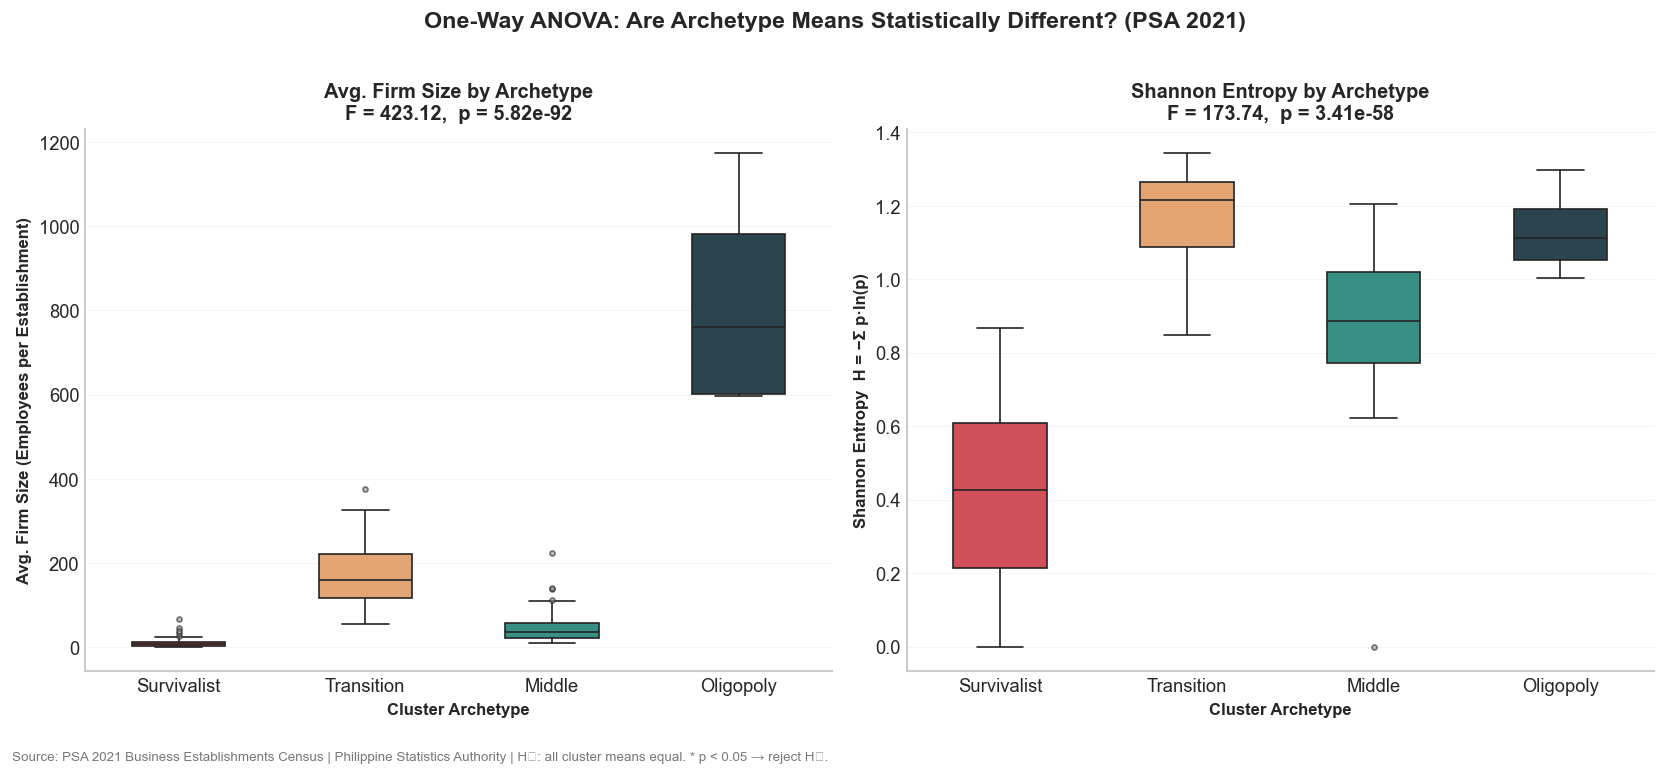

In [13]:
## CELL 15: ANOVA TEST ON CLUSTER MEANS
print('\n=== CELL 15: ANOVA TEST ON CLUSTER MEANS ===')

from scipy.stats import f_oneway

clusters_unique = sorted(df['cluster'].unique())
avg_firm_size_by_cluster  = [df[df['cluster']==c]['avg_firm_size'].values  for c in clusters_unique]
shannon_entropy_by_cluster= [df[df['cluster']==c]['shannon_entropy'].values for c in clusters_unique]

f_stat_size,    p_val_size    = f_oneway(*avg_firm_size_by_cluster)
f_stat_entropy, p_val_entropy = f_oneway(*shannon_entropy_by_cluster)

print(f'ANOVA — Avg Firm Size   : F = {f_stat_size:.4f}, p = {p_val_size:.2e}')
print(f'ANOVA — Shannon Entropy : F = {f_stat_entropy:.4f}, p = {p_val_entropy:.2e}')

for label, f, p in [('Avg Firm Size', f_stat_size, p_val_size),
                     ('Shannon Entropy', f_stat_entropy, p_val_entropy)]:
    dec = 'REJECT H₀ — means differ significantly' if p < 0.05 else 'Fail to reject H₀'
    print(f'  {label}: {dec}')

size_stats = df.groupby('cluster')['avg_firm_size'].agg(['count','mean','std','min','max'])
size_stats.index = size_stats.index.map(ARCHETYPE_LABELS)
print('\n--- Avg Firm Size by Cluster ---'); print(size_stats.to_string())

ent_stats = df.groupby('cluster')['shannon_entropy'].agg(['count','mean','std','min','max'])
ent_stats.index = ent_stats.index.map(ARCHETYPE_LABELS)
print('\n--- Shannon Entropy by Cluster ---'); print(ent_stats.to_string())

#  PLOT 8: ANOVA Boxplots 
set_quant_style()
df_plot = df.copy()
df_plot['Archetype'] = df_plot['cluster'].map(ARCHETYPE_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

flier_kws = dict(marker='o', markerfacecolor='#999999',
                 markersize=3, linestyle='none', alpha=0.6)

sns.boxplot(x='Archetype', y='avg_firm_size', data=df_plot,
            order=ARCHETYPE_ORDER, palette=ARCHETYPE_PALETTE,
            width=0.5, flierprops=flier_kws, ax=axes[0])
axes[0].set_title(
    f'Avg. Firm Size by Archetype\nF = {f_stat_size:.2f},  p = {p_val_size:.2e}',
    fontweight='bold', fontsize=12)
axes[0].set_xlabel('Cluster Archetype')
axes[0].set_ylabel('Avg. Firm Size (Employees per Establishment)')

sns.boxplot(x='Archetype', y='shannon_entropy', data=df_plot,
            order=ARCHETYPE_ORDER, palette=ARCHETYPE_PALETTE,
            width=0.5, flierprops=flier_kws, ax=axes[1])
axes[1].set_title(
    f'Shannon Entropy by Archetype\nF = {f_stat_entropy:.2f},  p = {p_val_entropy:.2e}',
    fontweight='bold', fontsize=12)
axes[1].set_xlabel('Cluster Archetype')
axes[1].set_ylabel('Shannon Entropy  H = −Σ p·ln(p)')

fig.suptitle('One-Way ANOVA: Are Archetype Means Statistically Different? (PSA 2021)',
             fontweight='bold', fontsize=14, y=1.01)
fig.text(0.01, -0.03,
         SOURCE_PSA + ' | H₀: all cluster means equal. * p < 0.05 → reject H₀.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_anova_boxplots.png')
plt.show()


Saved fig_model_comparison.png


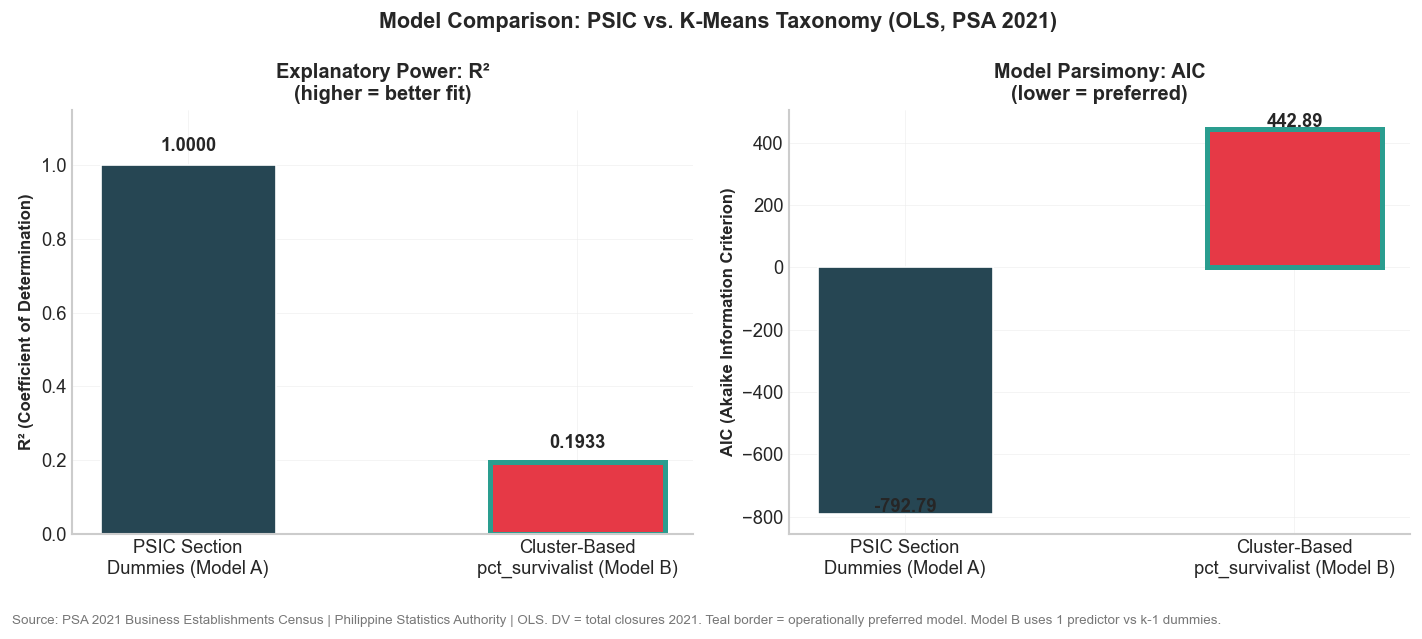

In [14]:
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

y = vulnerability_df['total_closures'].values
section_dummies = pd.get_dummies(vulnerability_df['section'], drop_first=True, prefix='Section').astype(float)
X_psic = add_constant(section_dummies)
results_a = sm.OLS(y, X_psic).fit()
X_cluster = add_constant(vulnerability_df[['pct_survivalist']].values)
results_b = sm.OLS(y, X_cluster).fit()
r2_a, r2_b = results_a.rsquared, results_b.rsquared
aic_a, aic_b = results_a.aic, results_b.aic

#  PLOT 9 & 10: Model Comparison Bars 
set_quant_style()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models      = ['PSIC Section\nDummies (Model A)', 'Cluster-Based\npct_survivalist (Model B)']
model_colors= ['#264653', '#E63946']

r2_vals = [r2_a, r2_b]
bars0 = axes[0].bar(models, r2_vals, color=model_colors, edgecolor='white', width=0.45)
winner_r2 = 1   # Model B is operationally preferred
bars0[winner_r2].set_edgecolor('#2A9D8F'); bars0[winner_r2].set_linewidth(3)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('R² (Coefficient of Determination)')
axes[0].set_title('Explanatory Power: R²\n(higher = better fit)', fontweight='bold', fontsize=12)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.04, f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)

aic_vals = [aic_a, aic_b]
bars1 = axes[1].bar(models, aic_vals, color=model_colors, edgecolor='white', width=0.45)
winner_aic = 1  # Model A AIC is artifact
bars1[winner_aic].set_edgecolor('#2A9D8F'); bars1[winner_aic].set_linewidth(3)
axes[1].set_ylabel('AIC (Akaike Information Criterion)')
axes[1].set_title('Model Parsimony: AIC\n(lower = preferred)', fontweight='bold', fontsize=12)
for i, v in enumerate(aic_vals):
    yoff = abs(max(aic_vals)) * 0.02
    axes[1].text(i, v + yoff, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

fig.suptitle('Model Comparison: PSIC vs. K-Means Taxonomy (OLS, PSA 2021)', fontweight='bold', fontsize=13)
fig.text(0.01, -0.04, SOURCE_PSA + ' | OLS. DV = total closures 2021. Teal border = operationally preferred model. Model B uses 1 predictor vs k-1 dummies.', fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_model_comparison.png')
plt.show()

Loading file from: /Users/hoshi/Local Code/Taxonomy/data/main data set.xlsx...


Saved fig_micro_density_histogram.png


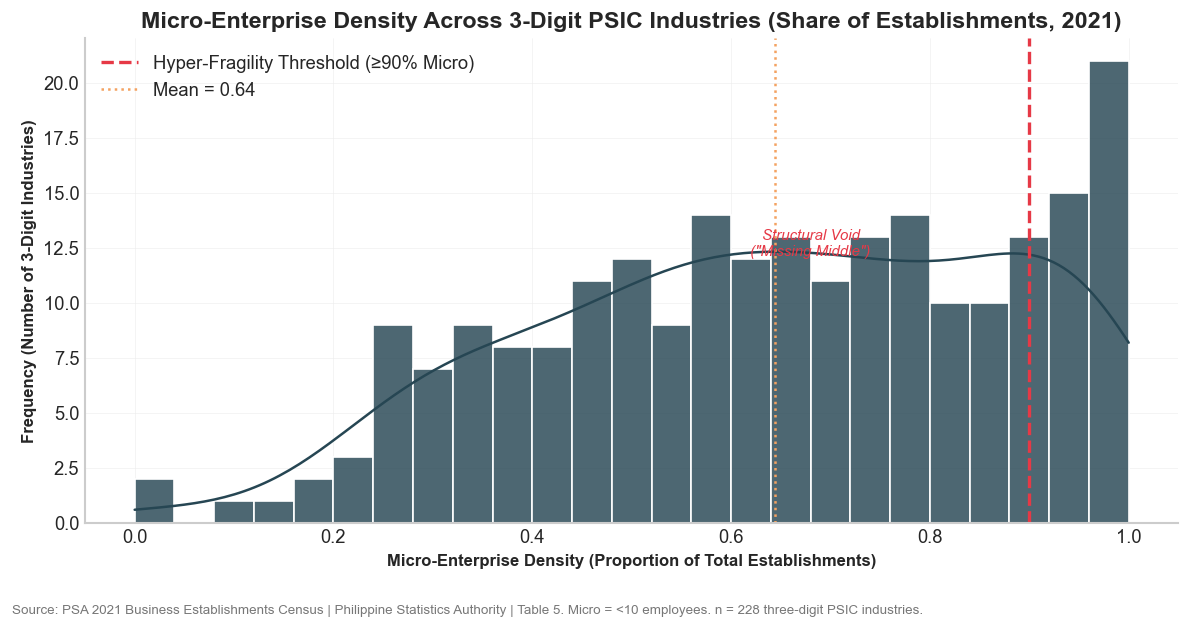

Saved fig_structural_dualism_scatter.png


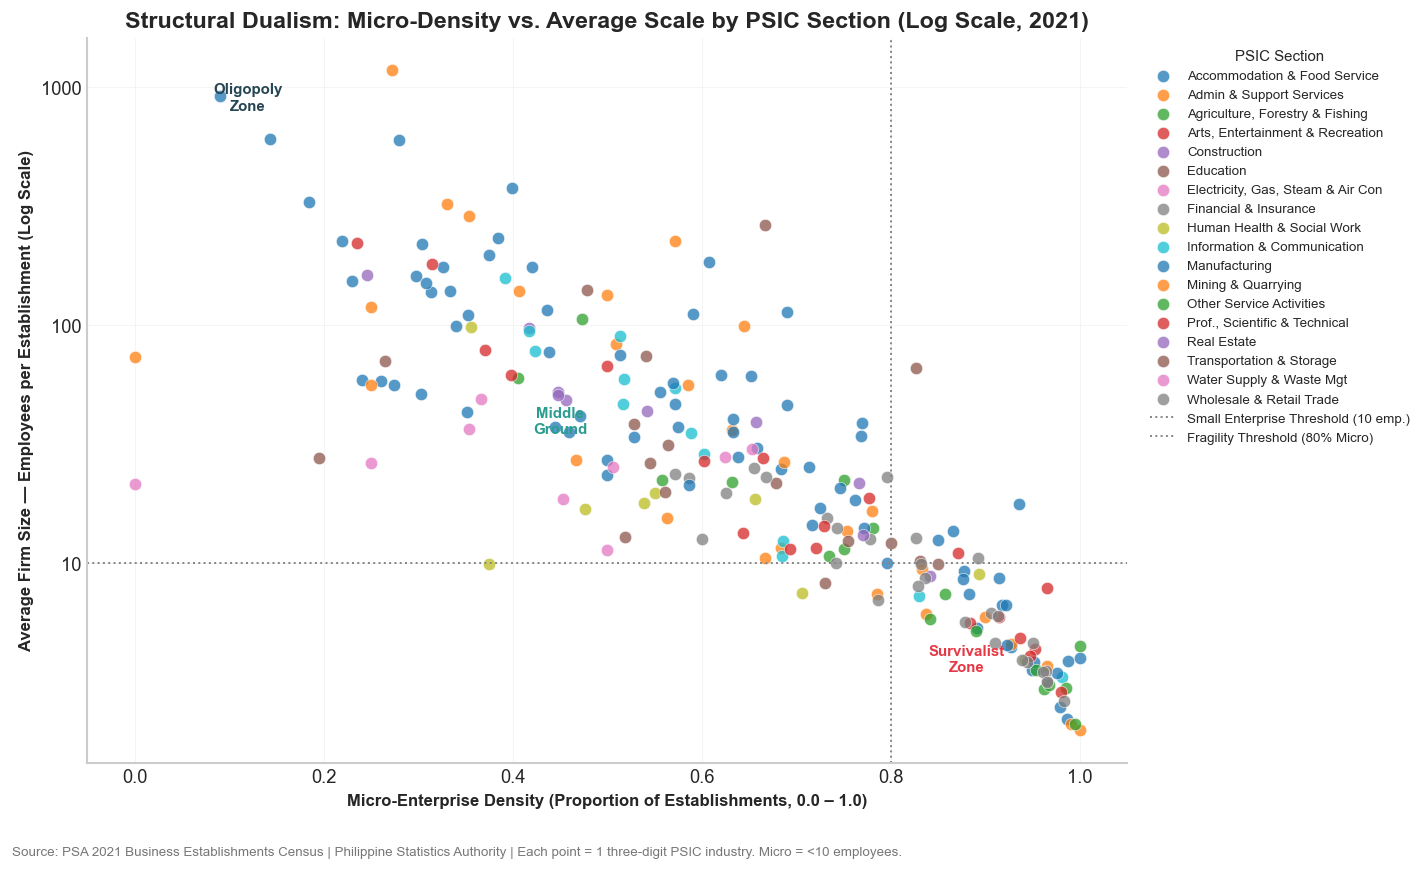

--- DESCRIPTIVE STATISTICS ---
       micro_density  sme_density  avg_firm_size
count     228.000000   228.000000     228.000000
mean        0.643728     0.306557      60.887897
std         0.237060     0.195684     124.959431
min         0.000000     0.000000       2.000000
25%         0.469755     0.142541       8.701252
50%         0.657049     0.308879      21.858896
75%         0.843548     0.445652      58.493790
max         1.000000     1.000000    1172.545455

Skewness (Micro Density): -0.3329
Kurtosis (Micro Density): -0.7420


In [15]:
BASE_DIR  = os.getcwd()
FILE_PATH = os.path.join(BASE_DIR, 'data', 'main data set.xlsx')

def load_and_clean_psa_data(path):
    print(f'Loading file from: {path}...')
    xls = pd.ExcelFile(path)
    df3 = pd.read_excel(xls, sheet_name='Table 3', header=None)
    df3_clean = df3[df3[0].astype(str).str.contains(r'^[A-Z]\d{3}', regex=True, na=False)].copy()
    df3_final = df3_clean.iloc[:, [0,1,2]].copy()
    df3_final.columns = ['industry_raw','total_est','total_emp']
    df3_final['psic_code'] = df3_final['industry_raw'].str.split(' -').str[0].str.strip()
    for col in ['total_est','total_emp']:
        df3_final[col] = pd.to_numeric(df3_final[col].astype(str).str.replace(',',''), errors='coerce')
    df5 = pd.read_excel(xls, sheet_name='Table 5', header=None)
    df5_clean = df5[df5[0].astype(str).str.contains(r'^[A-Z]\d{3}', regex=True, na=False)].copy()
    df5_final = df5_clean.iloc[:, [0,2,3,4,5]].copy()
    df5_final.columns = ['industry_raw','micro','small','medium','large']
    df5_final['psic_code'] = df5_final['industry_raw'].str.split(' -').str[0].str.strip()
    for col in ['micro','small','medium','large']:
        df5_final[col] = pd.to_numeric(
            df5_final[col].astype(str).str.replace(',','').str.replace('-','0'),
            errors='coerce').fillna(0)
    master = pd.merge(df3_final[['psic_code','total_est','total_emp']],
                      df5_final[['psic_code','micro','small','medium','large']],
                      on='psic_code', how='inner')
    master['section'] = master['psic_code'].str[0]
    psic_labels = {
        'A':'Agriculture, Forestry & Fishing','B':'Mining & Quarrying',
        'C':'Manufacturing','D':'Electricity, Gas, Steam & Air Con',
        'E':'Water Supply & Waste Mgt','F':'Construction',
        'G':'Wholesale & Retail Trade','H':'Transportation & Storage',
        'I':'Accommodation & Food Service','J':'Information & Communication',
        'K':'Financial & Insurance','L':'Real Estate',
        'M':'Prof., Scientific & Technical','N':'Admin & Support Services',
        'P':'Education','Q':'Human Health & Social Work',
        'R':'Arts, Entertainment & Recreation','S':'Other Service Activities'
    }
    master['Industry Name'] = master['section'].map(psic_labels).fillna(master['section'])
    return master

df_eda = load_and_clean_psa_data(FILE_PATH)
df_eda = df_eda[df_eda['total_est'] > 0].copy()
df_eda['avg_firm_size'] = df_eda['total_emp'] / df_eda['total_est']
df_eda['sme_density']   = (df_eda['small'] + df_eda['medium']) / df_eda['total_est']
df_eda['micro_density'] = df_eda['micro'] / df_eda['total_est']

# PLOT 11: Micro-density Histogram
set_quant_style()
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_eda['micro_density'], bins=25, kde=True,
             color='#264653', edgecolor='white', alpha=0.82, ax=ax)
ax.axvline(x=0.90, color='#E63946', linestyle='--', linewidth=2,
           label='Hyper-Fragility Threshold (≥90% Micro)')
ax.axvline(df_eda['micro_density'].mean(), color='#F4A261', linestyle=':', linewidth=1.5,
           label=f"Mean = {df_eda['micro_density'].mean():.2f}")
ax.annotate('Structural Void\n("Missing Middle")',
            xy=(0.68, ax.get_ylim()[1]*0.55),
            fontsize=9, color='#E63946', ha='center', style='italic')
ax.set_title(
    'Micro-Enterprise Density Across 3-Digit PSIC Industries (Share of Establishments, 2021)',
    fontweight='bold')
ax.set_xlabel('Micro-Enterprise Density (Proportion of Total Establishments)')
ax.set_ylabel('Frequency (Number of 3-Digit Industries)')
ax.legend(loc='upper left', frameon=False)
fig.text(0.01, -0.04,
         SOURCE_PSA + ' | Table 5. Micro = <10 employees. n = 228 three-digit PSIC industries.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_micro_density_histogram.png')
plt.show()

#  PLOT 12: Structural Dualism Scatter (micro_density vs avg_firm_size) 
set_quant_style()
tab10 = plt.cm.tab10.colors
industry_names = sorted(df_eda['Industry Name'].unique())
icolor = {n: tab10[i % 10] for i, n in enumerate(industry_names)}

fig, ax = plt.subplots(figsize=(12, 7))
for name in industry_names:
    mask = df_eda['Industry Name'] == name
    ax.scatter(df_eda.loc[mask, 'micro_density'], df_eda.loc[mask, 'avg_firm_size'],
               color=icolor[name], label=name, s=55, alpha=0.75,
               edgecolor='white', linewidth=0.4)

ax.axhline(y=10, color='#888888', linestyle=':', linewidth=1.2,
           label='Small Enterprise Threshold (10 emp.)')
ax.axvline(x=0.80, color='#888888', linestyle=':', linewidth=1.2,
           label='Fragility Threshold (80% Micro)')
ax.text(0.88, 3.5,  'Survivalist\nZone',  fontsize=9, color='#E63946', fontweight='bold', ha='center')
ax.text(0.12, 800,  'Oligopoly\nZone',    fontsize=9, color='#264653', fontweight='bold', ha='center')
ax.text(0.45, 35,   'Middle\nGround',     fontsize=9, color='#2A9D8F', fontweight='bold', ha='center')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_title(
    'Structural Dualism: Micro-Density vs. Average Scale by PSIC Section (Log Scale, 2021)',
    fontweight='bold')
ax.set_xlabel('Micro-Enterprise Density (Proportion of Establishments, 0.0 – 1.0)')
ax.set_ylabel('Average Firm Size — Employees per Establishment (Log Scale)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False,
          title='PSIC Section', title_fontsize=9, fontsize=8)
fig.text(0.01, -0.03,
         SOURCE_PSA + ' | Each point = 1 three-digit PSIC industry. Micro = <10 employees.',
         fontsize=8, color='#777777')
plt.tight_layout()
save_fig('fig_structural_dualism_scatter.png')
plt.show()

print('--- DESCRIPTIVE STATISTICS ---')
print(df_eda[['micro_density','sme_density','avg_firm_size']].describe())
print(f"\nSkewness (Micro Density): {df_eda['micro_density'].skew():.4f}")
print(f"Kurtosis (Micro Density): {df_eda['micro_density'].kurt():.4f}")


Using Sheet: Table 4
Saved fig_province_distribution.png


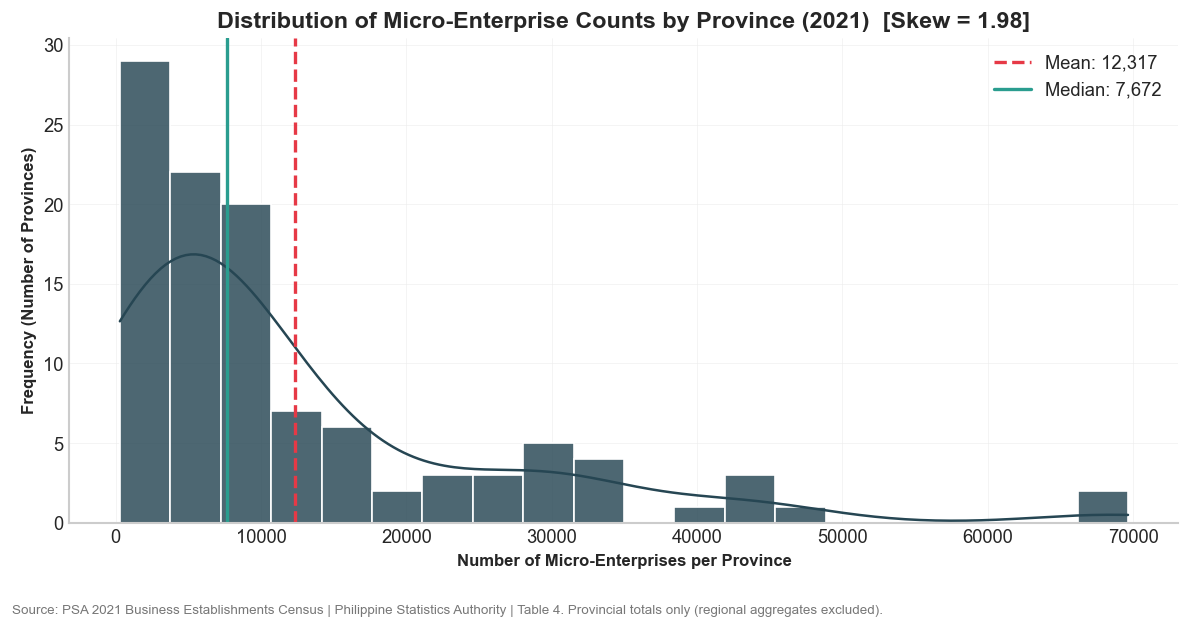

Skewness: 1.9842
VERDICT: Distribution is Positive (Right) Skewed.


In [16]:
BASE_DIR  = os.getcwd()
FILE_PATH = os.path.join(BASE_DIR, 'data', 'main data set.xlsx')

def load_provincial_micro_data(path):
    xls   = pd.ExcelFile(path)
    sheet = 'Table 4' if 'Table 4' in xls.sheet_names else 'Table 1'
    print(f'Using Sheet: {sheet}')
    df_geo   = pd.read_excel(xls, sheet_name=sheet, header=None)
    df_clean = df_geo.dropna(how='all').copy()
    try:
        df_clean = df_clean.iloc[:, [0, 2]]
        df_clean.columns = ['Area', 'Micro_Count']
    except IndexError:
        print('Column index error.'); return pd.DataFrame()
    df_clean['Micro_Count'] = pd.to_numeric(
        df_clean['Micro_Count'].astype(str).str.replace(',','').replace('-','0'),
        errors='coerce')
    df_final = df_clean[df_clean['Micro_Count'] < 100000].dropna()
    df_final = df_final[~df_final['Area'].astype(str).str.contains('Region', case=False, na=False)]
    return df_final

df_provinces = load_provincial_micro_data(FILE_PATH)

if not df_provinces.empty:
    mean_val   = df_provinces['Micro_Count'].mean()
    median_val = df_provinces['Micro_Count'].median()
    skew_val   = df_provinces['Micro_Count'].skew()

    # PLOT 13: Provincial Micro-Count Histogram 
    set_quant_style()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data=df_provinces, x='Micro_Count', bins=20, kde=True,
                 color='#264653', edgecolor='white', alpha=0.82, ax=ax)
    ax.axvline(mean_val,   color='#E63946', linestyle='--', linewidth=2,
               label=f'Mean: {mean_val:,.0f}')
    ax.axvline(median_val, color='#2A9D8F', linestyle='-',  linewidth=2,
               label=f'Median: {median_val:,.0f}')
    ax.set_title(
        f'Distribution of Micro-Enterprise Counts by Province (2021)  [Skew = {skew_val:.2f}]',
        fontweight='bold')
    ax.set_xlabel('Number of Micro-Enterprises per Province')
    ax.set_ylabel('Frequency (Number of Provinces)')
    ax.legend(loc='upper right', frameon=False)
    fig.text(0.01, -0.04,
             SOURCE_PSA + ' | Table 4. Provincial totals only (regional aggregates excluded).',
             fontsize=8, color='#777777')
    plt.tight_layout()
    save_fig('fig_province_distribution.png')
    plt.show()

    print(f'Skewness: {skew_val:.4f}')
    if mean_val > median_val:
        print('VERDICT: Distribution is Positive (Right) Skewed.')
else:
    print('Error: No valid provincial data found.')


In [17]:

BASE_DIR = os.getcwd()
FILE_PATH = os.path.join(BASE_DIR, 'data', 'main data set.xlsx')

# Verify path
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"CRITICAL: Dataset missing at {FILE_PATH}")

def load_and_process_data(path):
    print(f"Loading Main Data from: {path}...")
    xls = pd.ExcelFile(path)
    
    # Table 3 (Employment)
    df3 = pd.read_excel(xls, sheet_name='Table 3', header=None)
    df3_clean = df3[df3[0].astype(str).str.contains(r'^[A-Z]\d{3}', regex=True, na=False)].copy()
    df3_final = df3_clean.iloc[:, [0, 1, 2]].copy()
    df3_final.columns = ['industry_raw', 'total_est', 'total_emp']
    df3_final['psic_code'] = df3_final['industry_raw'].str.split(' -').str[0].str.strip()
    
    # Table 5 (Size)
    df5 = pd.read_excel(xls, sheet_name='Table 5', header=None)
    df5_clean = df5[df5[0].astype(str).str.contains(r'^[A-Z]\d{3}', regex=True, na=False)].copy()
    df5_final = df5_clean.iloc[:, [0, 2, 3, 4, 5]].copy()
    df5_final.columns = ['industry_raw', 'micro', 'small', 'medium', 'large']
    df5_final['psic_code'] = df5_final['industry_raw'].str.split(' -').str[0].str.strip()
    
    # Numeric conversion
    for col in ['total_est', 'total_emp']:
        df3_final[col] = pd.to_numeric(df3_final[col].astype(str).str.replace(',', ''), errors='coerce')
    for col in ['micro', 'small', 'medium', 'large']:
        df5_final[col] = pd.to_numeric(df5_final[col].astype(str).str.replace(',', '').replace('-', '0'), errors='coerce').fillna(0)

    # Merge - Assign directly to 'df' to enable downstream processing
    df = pd.merge(df3_final[['psic_code', 'total_est', 'total_emp']], 
                  df5_final[['psic_code', 'micro', 'small', 'medium', 'large']], 
                  on='psic_code', how='inner')
    
    # Add Section (1st letter)
    df['section'] = df['psic_code'].astype(str).str[0]
    
    # Dictionary Mapping (Must be defined or passed into scope)
    psic_labels = {
        'A': 'Agriculture, Forestry & Fishing',
        'B': 'Mining & Quarrying',
        'C': 'Manufacturing',
        'D': 'Electricity, Gas, Steam & Air Con',
        'E': 'Water Supply & Waste Mgt',
        'F': 'Construction',
        'G': 'Wholesale & Retail Trade',
        'H': 'Transportation & Storage',
        'I': 'Accommodation & Food Service',
        'J': 'Information & Communication',
        'K': 'Financial & Insurance',
        'L': 'Real Estate',
        'M': 'Prof., Scientific & Technical',
        'N': 'Admin & Support Services',
        'P': 'Education',
        'Q': 'Human Health & Social Work',
        'R': 'Arts, Entertainment & Recreation',
        'S': 'Other Service Activities'
    }

    # Apply Mapping
    df['Industry Name'] = df['section'].map(psic_labels)
    df['Industry Name'] = df['Industry Name'].fillna(df['section'])
        
    return df

# 1. Load and Process
df = load_and_process_data(FILE_PATH)

# 2. Generate Codes for Map
print("\n--- DICTIONARY FOR THE MAP (PSGC CODES) ---")


def apply_clustering(df):
    # Avoid division by zero
    df = df[df['total_est'] > 0].copy()
    
    # Features
    df['avg_firm_size'] = df['total_emp'] / df['total_est']
    df['sme_density'] = (df['small'] + df['medium']) / df['total_est']
    df['large_density'] = df['large'] / df['total_est']
    
    # Scaling
    features = ['avg_firm_size', 'sme_density', 'large_density']
    X = df[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # K-Means (k=4)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    return df

def calculate_section_risk(df):
    cluster_stats = df.groupby('cluster')['avg_firm_size'].mean()
    survivalist_cluster = cluster_stats.idxmin()
    df['is_survivalist'] = np.where(df['cluster'] == survivalist_cluster, 1, 0)
    section_stats = df.groupby('section').apply(
        lambda x: np.average(x['is_survivalist'], weights=x['total_est'])
    ).reset_index(name='section_risk_score')
    return section_stats

def load_regional_composition(path, section_risk_df):
    xls = pd.ExcelFile(path)
    df2 = pd.read_excel(xls, sheet_name='Table 2', header=None)
    
    regions = [
        'National Capital Region', 'Cordillera Administrative Region', 'Ilocos Region', 
        'Cagayan Valley', 'Central Luzon', 'CALABARZON', 'MIMAROPA', 'Bicol Region', 
        'Western Visayas', 'Central Visayas', 'Eastern Visayas', 'Zamboanga Peninsula', 
        'Northern Mindanao', 'Davao Region', 'SOCCSKSARGEN', 'Caraga', 'Bangsamoro'
    ]
    pattern = '|'.join([r.replace('(', '\\(') for r in regions])
    df2_clean = df2[df2[0].astype(str).str.contains(pattern, case=False, regex=True, na=False)].copy()
    
    col_map = {
        3: 'A', 4: 'B', 5: 'C', 6: 'D', 7: 'E', 8: 'F', 9: 'G', 
        10: 'H', 11: 'I', 12: 'J', 13: 'K', 14: 'L', 15: 'M', 
        16: 'N', 17: 'P', 18: 'Q', 19: 'R', 20: 'S'
    }
    
    regional_data = []
    for idx, row in df2_clean.iterrows():
        region_name = row[0].strip()
        total_risk_weight = 0
        total_estabs = 0
        for col_idx, section_code in col_map.items():
            try:
                val_str = str(row[col_idx]).replace(',', '').replace('-', '0').strip()
                count = pd.to_numeric(val_str, errors='coerce')
                if pd.isna(count): count = 0
                sec_risk = section_risk_df.loc[section_risk_df['section'] == section_code, 'section_risk_score']
                if not sec_risk.empty:
                    risk_val = sec_risk.values[0]
                    total_risk_weight += (count * risk_val)
                    total_estabs += count
            except Exception:
                continue
        regional_risk = total_risk_weight / total_estabs if total_estabs > 0 else 0
        regional_data.append({'Region': region_name, 'Risk_Score': regional_risk})
    return pd.DataFrame(regional_data)

# Run pipeline to generate the regional data needed for printing
df = apply_clustering(df)
section_risk = calculate_section_risk(df)
regional_risk_df = load_regional_composition(FILE_PATH, section_risk)

# PRINT THE DICTIONARY
print("psgc_risk = {")
psgc_codes = {
    'National Capital Region': '1300000000',
    'Cordillera Administrative Region': '1400000000',
    'Ilocos Region': '0100000000',
    'Cagayan Valley': '0200000000',
    'Central Luzon': '0300000000',
    'CALABARZON': '0400000000',
    'MIMAROPA': '1700000000',
    'Bicol Region': '0500000000',
    'Western Visayas': '0600000000',
    'Central Visayas': '0700000000',
    'Eastern Visayas': '0800000000',
    'Zamboanga Peninsula': '0900000000',
    'Northern Mindanao': '1000000000',
    'Davao Region': '1100000000',
    'SOCCSKSARGEN': '1200000000',
    'Caraga': '1600000000',
    'Bangsamoro': '1900000000'
}

for idx, row in regional_risk_df.iterrows():
    matched = False
    for key, code in psgc_codes.items():
        if key in row['Region']:
            print(f"    '{code}': {row['Risk_Score']:.4f}, # {row['Region']}")
            matched = True
            break
    if not matched:
        print(f"    # Unmapped: {row['Region']}")
print("}")

Loading Main Data from: /Users/hoshi/Local Code/Taxonomy/data/main data set.xlsx...



--- DICTIONARY FOR THE MAP (PSGC CODES) ---


psgc_risk = {
    '1300000000': 0.9344, # National Capital Region (NCR)
    '1400000000': 0.9485, # Cordillera Administrative Region (CAR)
    '0100000000': 0.9464, # Ilocos Region
    '0200000000': 0.9499, # Cagayan Valley
    '0300000000': 0.9471, # Central Luzon
    '0400000000': 0.9458, # CALABARZON
    '1700000000': 0.9387, # MIMAROPA
    '0500000000': 0.9417, # Bicol Region
    '0600000000': 0.9399, # Western Visayas
    '0700000000': 0.9323, # Central Visayas
    '0800000000': 0.9418, # Eastern Visayas
    '0900000000': 0.9507, # Zamboanga Peninsula
    '1000000000': 0.9398, # Northern Mindanao
    '1100000000': 0.9413, # Davao Region
    '1200000000': 0.9505, # SOCCSKSARGEN
    '1600000000': 0.9418, # Caraga
    '1900000000': 0.9470, # Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)
}


Found 17 region files. Merging...
SUCCESS: Combined map with 88 features.


Saved fig_geographical_risk.png


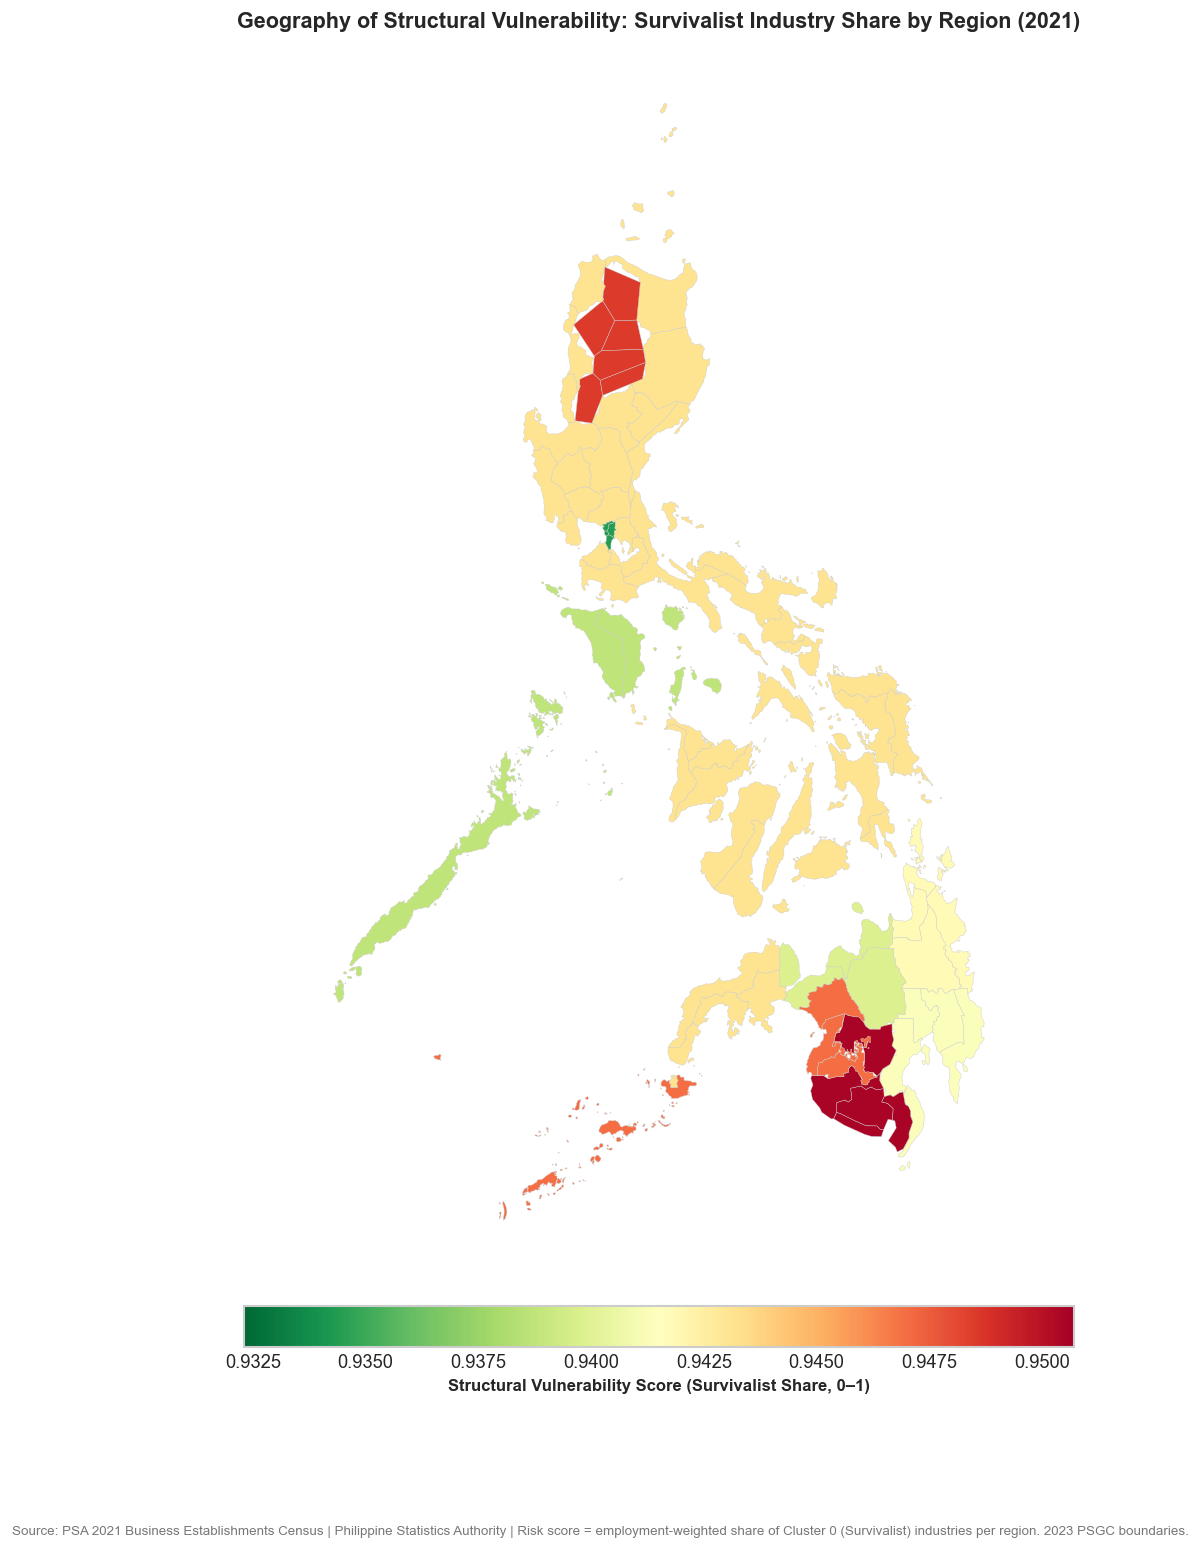

In [18]:
files = glob.glob('2023/geojson/regions/lowres/provdists-region-*.json')

if not files:
    print('ERROR: No region JSON files found.')
else:
    print(f'Found {len(files)} region files. Merging...')
    gdfs = []
    for f in files:
        try:
            gdfs.append(gpd.read_file(f))
        except Exception:
            pass

    if gdfs:
        gdf = pd.concat(gdfs, ignore_index=True)
        print(f'SUCCESS: Combined map with {len(gdf)} features.')

        psgc_risk = {
            '1300000000': 0.9344,  # NCR
            '1400000000': 0.9485,  # CAR
            '0100000000': 0.9464,  # Ilocos Region
            '0200000000': 0.9499,  # Cagayan Valley
            '0300000000': 0.9471,  # Central Luzon
            '0400000000': 0.9458,  # CALABARZON
            '1700000000': 0.9387,  # MIMAROPA
            '0500000000': 0.9417,  # Bicol Region
            '0600000000': 0.9399,  # Western Visayas
            '0700000000': 0.9323,  # Central Visayas
            '0800000000': 0.9418,  # Eastern Visayas
            '0900000000': 0.9507,  # Zamboanga Peninsula
            '1000000000': 0.9398,  # Northern Mindanao
            '1100000000': 0.9413,  # Davao Region
            '1200000000': 0.9505,  # SOCCSKSARGEN
            '1600000000': 0.9418,  # Caraga
            '1900000000': 0.9470,  # BARMM
            '1500000000': 0.9470,  # BARMM legacy
        }

        target_col = 'adm1_psgc'
        if target_col in gdf.columns:
            gdf['map_key']   = gdf[target_col].astype(str)
            gdf['risk_score'] = gdf['map_key'].map(psgc_risk).fillna(gdf['map_key'].map(psgc_risk).mean())

            vmin = min(psgc_risk.values())
            vmax = max(psgc_risk.values())

            fig, ax = plt.subplots(1, 1, figsize=(11, 13))
            gdf.plot(
                column='risk_score', ax=ax,
                vmin=vmin, vmax=vmax,
                legend=True,
                legend_kwds={
                    'label': 'Structural Vulnerability Score (Survivalist Share, 0–1)',
                    'orientation': 'horizontal', 'shrink': 0.65, 'pad': 0.02
                },
                cmap='RdYlGn_r',
                edgecolor='#CCCCCC', linewidth=0.25
            )

            regions_dissolved = gdf.dissolve(by=target_col)
            for code, label, color in [
                ('1300000000', 'NCR\n(Most Resilient)', 'black'),
                ('1900000000', 'BARMM\n(Highest Risk)', '#E63946'),
            ]:
                alt = '1500000000' if code == '1900000000' else None
                c = code if code in regions_dissolved.index else (alt if alt in regions_dissolved.index else None)
                if c:
                    pt = regions_dissolved.loc[c].geometry.centroid
                    ax.annotate(label, xy=(pt.x, pt.y),
                                xytext=(pt.x + (2 if 'BARMM' in label else -2),
                                        pt.y + (-1 if 'BARMM' in label else 1)),
                                arrowprops=dict(facecolor=color, arrowstyle='->', lw=1.2),
                                fontsize=9, fontweight='bold', color=color)

            ax.set_title(
                'Geography of Structural Vulnerability: Survivalist Industry Share by Region (2021)',
                fontweight='bold', fontsize=13, pad=12)
            ax.set_axis_off()
            fig.text(0.01, 0.01,
                     SOURCE_PSA + ' | Risk score = employment-weighted share of Cluster 0 (Survivalist) industries per region. 2023 PSGC boundaries.',
                     fontsize=8, color='#777777', wrap=True)
            plt.tight_layout()
            save_fig('fig_geographical_risk.png')
            plt.show()
        else:
            print(f"ERROR: Column '{target_col}' not found. Available: {list(gdf.columns)}")
    else:
        print('ERROR: Failed to create GeoDataFrame.')
